# Predicting Customer Churn

This project aims to predict customer churn using machine learning techniques and translate model outputs into actionable business insights.

The approach follows a structured pipeline:

Establishing a baseline model
Building and improving predictive models
Evaluating performance using appropriate metrics
Segmenting customers using clustering
Applying optimisation to support retention strategy

The ultimate goal is not only to predict churn, but to support better decision-making in customer retention.

## Data Import and Overview

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import warnings
warnings.filterwarnings('ignore')

### Data Preparation and Initial Analysis

The data set contains observations of which customers churned.

In [100]:
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')

In [101]:
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


The dataset contains behavioural and demographic information about customers, including engagement, purchase activity, and service interactions.  
The target variable *Churned* indicates whether a customer has left (1) or stayed (0).

In [102]:
df['Churned'].value_counts().rename({0: 'Retained', 1: 'Churned'})

Churned
Retained    35550
Churned     14450
Name: count, dtype: int64

## Data Cleaning and Preprocessing

In [103]:
#data sctructure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

The dataset contains both numerical and categorical variables. Categorical features will be encoded before modelling.

In [104]:
#data quality
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

Number of

The dataset contains minimal missing values and no significant duplicates, indicating good data quality.

In [105]:
#target distribution
df['Churned'].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

The dataset is moderately imbalanced, with more retained than churned customers. This is important when evaluating model performance.

1. Separate the data into:
X = input features
y = target/output
2. Split the data into:
training data
testing data

In [106]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Churned', axis=1)
y = df_encoded['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=22)

print(type(X_train), type(y_train))
print(X_train.shape, y_train.shape)

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>
(37500, 71) (37500,)


## Dummy Classifier as my baseline

A Dummy Classifier was used as a baseline model. It does not learn patterns from the data; instead, it predicts the most frequent class. This provides a simple benchmark to compare whether the Decision Tree and Random Forest models add meaningful predictive value.

In [107]:
dummy = DummyClassifier(strategy='most_frequent', random_state=22)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Dummy train accuracy:", dummy.score(X_train, y_train))
print("Dummy test accuracy:", dummy.score(X_test, y_test))

print(classification_report(y_test, y_pred_dummy))

Dummy train accuracy: 0.7111733333333333
Dummy test accuracy: 0.71048
              precision    recall  f1-score   support

           0       0.71      1.00      0.83      8881
           1       0.00      0.00      0.00      3619

    accuracy                           0.71     12500
   macro avg       0.36      0.50      0.42     12500
weighted avg       0.50      0.71      0.59     12500



The Dummy Classifier provides a baseline accuracy based on predicting the majority class. Since most customers are retained, the model is expected to perform reasonably on overall accuracy but poorly at identifying churned customers.
This highlights that accuracy alone is misleading in churn problems, and reinforces the need for models that can correctly identify churned customers.

## Decision Tree Modelling

Decision Tree Classifier for initial modelling

After establishing a baseline, a Decision Tree model is used as the first predictive model to capture patterns in customer behaviour.

I am using Decision Tree Classifier to fit a model tree_1 on the training data with all default settings. This will score the data using accuracy on the train and test data.

In [108]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

model.score(X_train, y_train)
model.score(X_test, y_test)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Train accuracy: 0.9988266666666666
Test accuracy: 0.8448


The model achieves nearly perfect accuracy on the training data but lower accuracy on the test data, indicating overfitting. This suggests the model is memorising the training data rather than generalising well to new data.

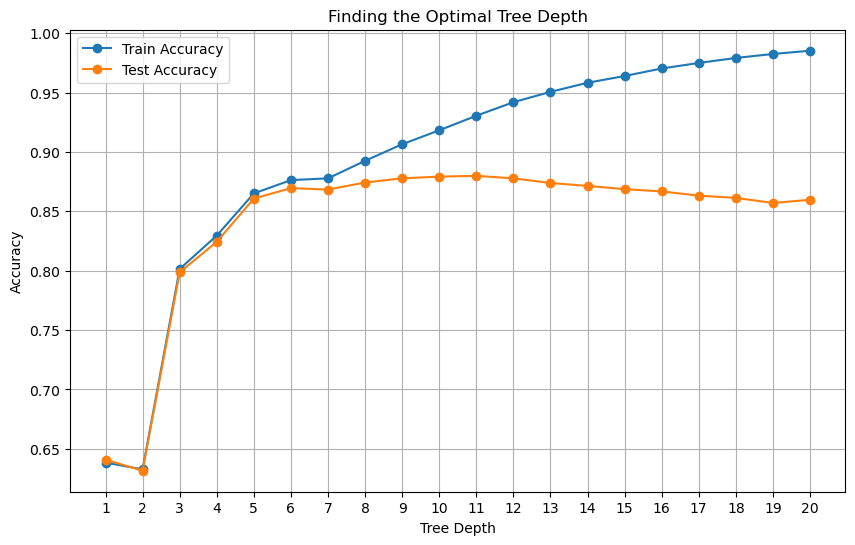

In [109]:
# Test different depths from 1 to 20
depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    # We use 'balanced' to help the model see the churned customers better
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=22)
    dt.fit(X_train, y_train)
    
    train_scores.append(dt.score(X_train, y_train))
    test_scores.append(dt.score(X_test, y_test))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Finding the Optimal Tree Depth')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

The graph shows that while training accuracy continues to increase with tree depth, test accuracy peaks around depth = 10 before declining.
This indicates that deeper trees begin to overfit the training data, capturing noise rather than meaningful patterns.
Therefore, depth = 10 is selected as the optimal balance between performance and generalisation.

In [110]:
model = DecisionTreeClassifier(max_depth=10)
model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Train accuracy: 0.92584
Test accuracy: 0.88488


By optimising the maximum depth of the decision tree, I found the best balance between complexity and performance. This reduced the initial overfitting seen in the default model and resulted in more balanced training and testing accuracy, indicating much better generalisation to new data.

In [111]:
dt_final = DecisionTreeClassifier(max_depth=10, random_state=22)
dt_final.fit(X_train, y_train)

print("Train accuracy:", dt_final.score(X_train, y_train))
print("Test accuracy:", dt_final.score(X_test, y_test))

y_pred_dt = dt_final.predict(X_test)

print(classification_report(y_test, y_pred_dt))

Train accuracy: 0.9257066666666667
Test accuracy: 0.88488
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      8881
           1       0.85      0.73      0.79      3619

    accuracy                           0.88     12500
   macro avg       0.87      0.84      0.85     12500
weighted avg       0.88      0.88      0.88     12500



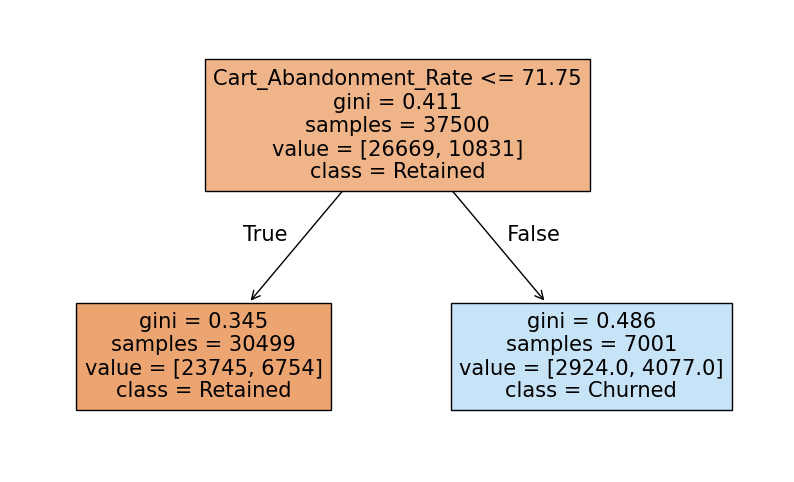

In [112]:
model = DecisionTreeClassifier(max_depth=1, random_state=22)
model.fit(X_train, y_train)

plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X_train.columns, class_names=['Retained', 'Churned'], filled=True)
plt.show()

A shallow Decision Tree was used for interpretability, while a tuned Decision Tree was used for final model evaluation.

### Interpretation
- Customers with low cart abandonment rates (≤ 71.75) are more likely to be retained
- Customers with high cart abandonment rates (> 71.75) are more likely to churn

### Business Insight

The decision tree identifies Cart Abandonment Rate as the most important feature, as it is used in the first split of the model. This suggests that customer engagement during the purchase journey plays a critical role in retention.

Customers who frequently abandon their carts are significantly more likely to churn, indicating potential friction in the buying process or lack of purchase intent.

While the dataset is slightly imbalanced, with more retained customers than churned customers, the model highlights a clear behavioural pattern: higher abandonment is a strong signal of disengagement and churn risk.

From a business perspective, reducing cart abandonment through improved user experience, targeted reminders, or incentives could help improve customer retention.

## Improving Decision Tree

I improved the Decision Tree model by testing different depths and pruning techniques. This helped balance accuracy and complexity, ensuring the model generalizes well to new data without overfitting.


In [113]:
depths = list(range(1, 21))
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=22)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

I selected the tree depth by comparing training and testing performance across multiple values, rather than choosing it arbitrarily.

While depth tuning controls the overall complexity of the tree, pruning provides a more refined approach by removing less important splits that do not contribute significantly to predictive performance.

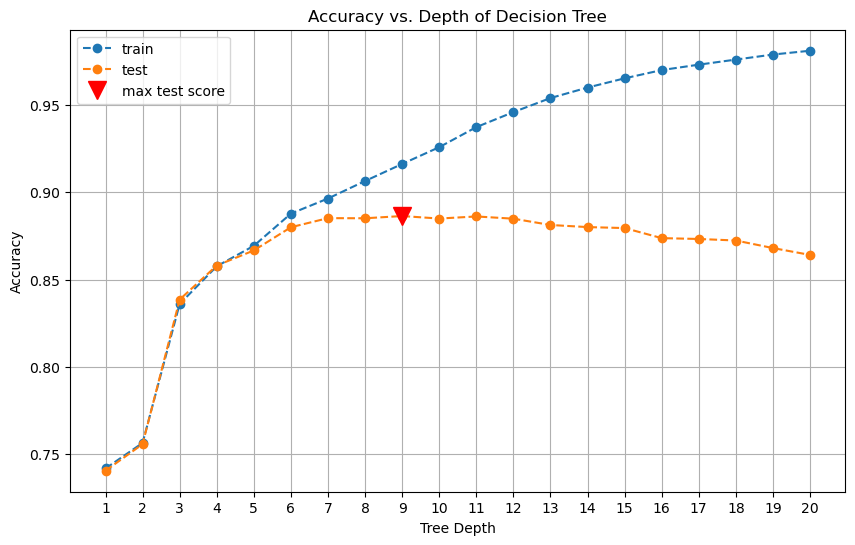

In [114]:
depths = list(range(1, 21))

train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=22)
    tree.fit(X_train, y_train)

    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(10,6))
plt.plot(depths, train_scores, '--o', label='train')
plt.plot(depths, test_scores, '--o', label='test')
plt.title('Accuracy vs. Depth of Decision Tree')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.plot(np.argmax(test_scores)+1, max(test_scores),
         'v', markersize=13, color='red',
         label='max test score')
plt.legend()
plt.grid()
plt.show()

Decision trees can become too complex if they are allowed to grow without limits. A very deep tree may learn the training data too closely, including small patterns or noise that may not be useful for new data. This means it can perform well on the training set but less well on the test set.

To reduce this risk, pruning is used to make the tree simpler. Pruning removes parts of the tree that do not add much value to the model’s predictions. This can help the model focus on the most important patterns and perform better on unseen data.

In this section, I tested different pruning strengths using the ccp_alpha parameter. By comparing the training and test accuracy at each value, I can see how pruning affects the model and choose a level that gives a better balance between accuracy and generalisation.

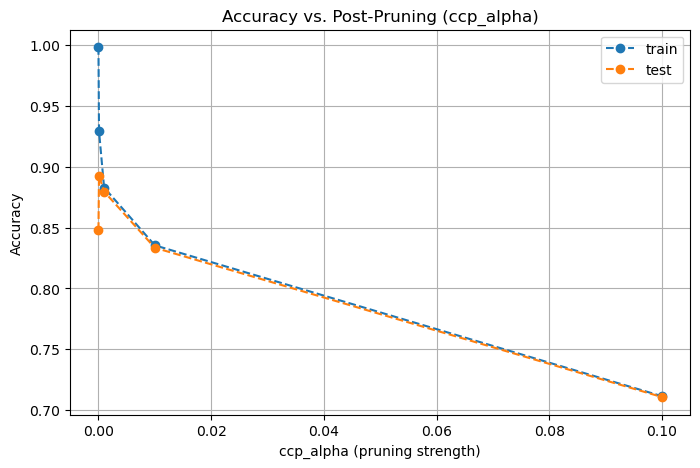

Best alpha: 0.0001
Best test accuracy: 0.89256


In [115]:
# try different pruning strengths
alphas = [0, 0.0001, 0.001, 0.01, 0.1]

ccp_train_scores = []
ccp_test_scores = []

for alpha in alphas:
    tree = DecisionTreeClassifier(ccp_alpha=alpha, random_state=22)
    tree.fit(X_train, y_train)

    ccp_train_scores.append(tree.score(X_train, y_train))
    ccp_test_scores.append(tree.score(X_test, y_test))

# plot results
plt.figure(figsize=(8,5))
plt.plot(alphas, ccp_train_scores, '--o', label='train')
plt.plot(alphas, ccp_test_scores, '--o', label='test')
plt.xlabel('ccp_alpha (pruning strength)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. Post-Pruning (ccp_alpha)')
plt.legend()
plt.grid()
plt.show()

# best alpha
best_idx = np.argmax(ccp_test_scores)
print("Best alpha:", alphas[best_idx])
print("Best test accuracy:", ccp_test_scores[best_idx])

## Confusion Matrix
Evaluation of Model Performance

To evaluate the performance of the Decision Tree model beyond overall accuracy, I used a confusion matrix. While accuracy provides a general measure of performance, it can be misleading in imbalanced datasets. The confusion matrix gives a detailed breakdown of correct and incorrect predictions for both retained and churned customers, allowing for a more comprehensive assessment of how well the model identifies customers at risk of churn.




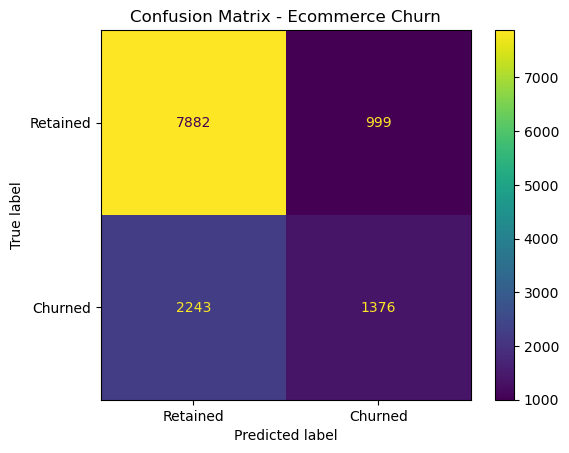

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# predictions
y_pred = model.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='viridis')
plt.title("Confusion Matrix - Ecommerce Churn")
plt.show()

In [117]:
from sklearn.metrics import classification_report

# Classification Report
# To further evaluate the model's performance, a classification report is generated.
# The classification report provides additional metrics beyond the confusion matrix,
# including precision, recall, F1-score, and support for each class.
# This gives a more comprehensive understanding of the model's strengths and weaknesses
# in predicting the different classes (retained and churned customers).

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.89      0.83      8881
           1       0.58      0.38      0.46      3619

    accuracy                           0.74     12500
   macro avg       0.68      0.63      0.64     12500
weighted avg       0.72      0.74      0.72     12500



### Interpretation

The results show that the model correctly classified 7,882 retained customers, while incorrectly predicting 999 retained customers as churned. For churned customers, the model correctly identified 1,376 cases, but failed to detect 2,243 churned customers, misclassifying them as retained.

This indicates that the model performs well in identifying retained customers but struggles to correctly detect churned customers. This is further reflected in the classification report, where recall for churned customers is relatively low at 38%, compared to 89% for retained customers.

From a business perspective, this is a critical limitation. Missing churned customers means that high-risk individuals may not be targeted with retention strategies, reducing the effectiveness of intervention efforts. Therefore, improving the model’s ability to detect churned customers (recall) is more important than simply maximising overall accuracy.

## Random Forest Modelling and Evaluation

To improve predictive performance and reduce overfitting, a Random Forest model is applied. This ensemble method combines multiple decision trees to produce more robust and generalisable predictions.

In [118]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
rf = RandomForestClassifier(random_state=22)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=22)

In [120]:
print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", rf.score(X_test, y_test))

Train accuracy: 0.9998933333333333
Test accuracy: 0.91032


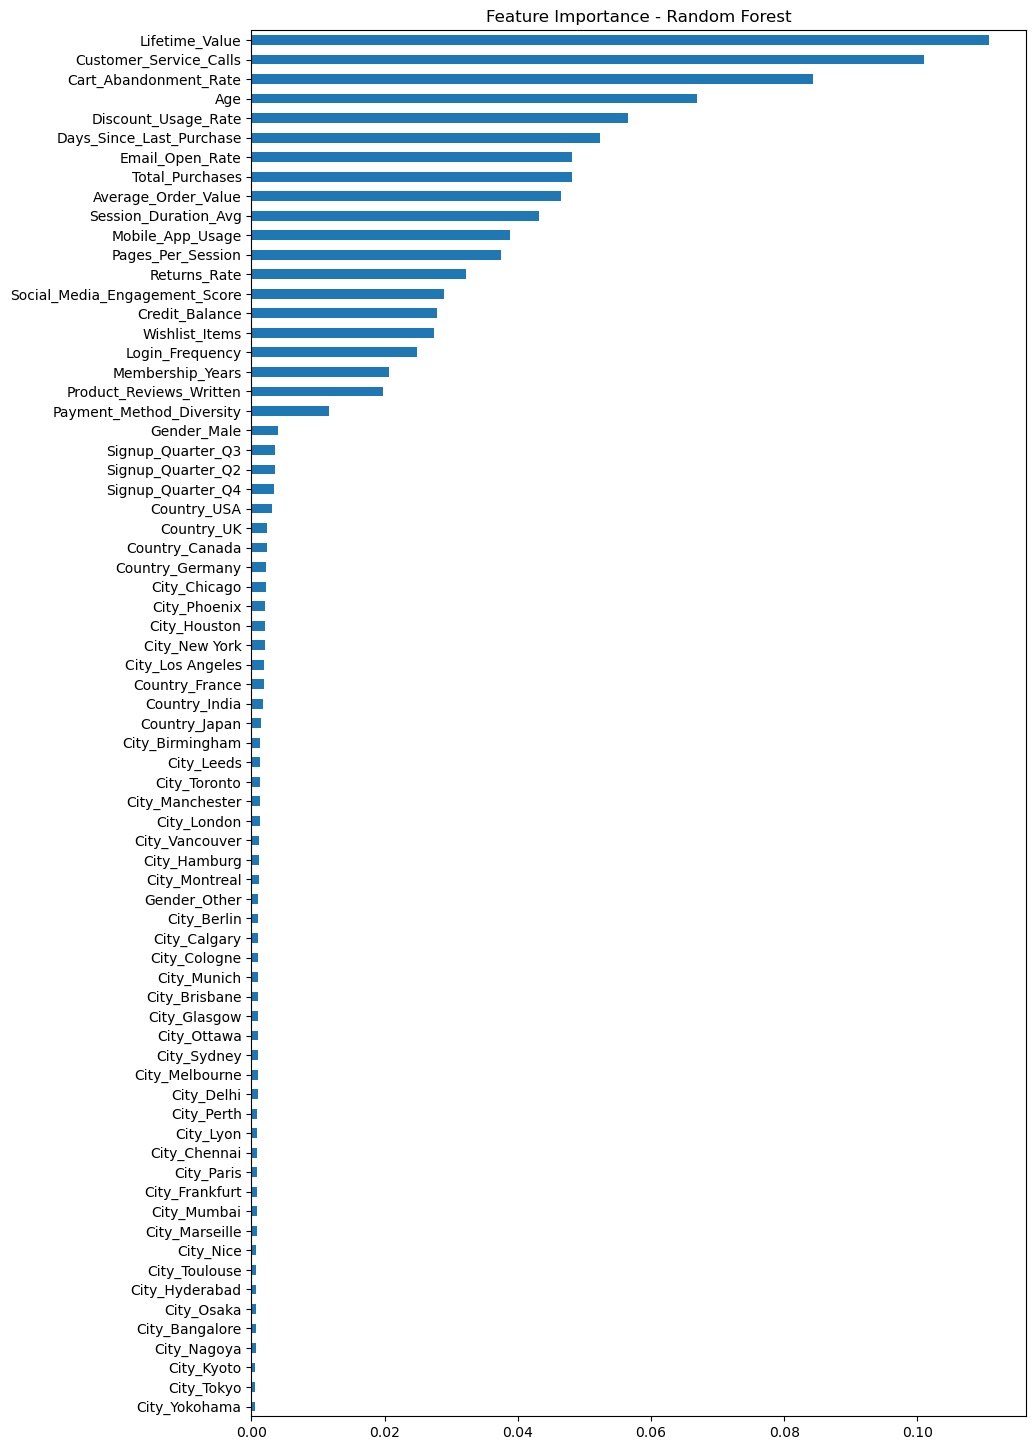

In [121]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values().plot(kind='barh', figsize=(10,18))
plt.title("Feature Importance - Random Forest")
plt.show()

In [122]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=22
)

rf.fit(X_train, y_train)

print("Train accuracy:", rf.score(X_train, y_train))
print("Test accuracy:", rf.score(X_test, y_test))

Train accuracy: 0.8837333333333334
Test accuracy: 0.86624


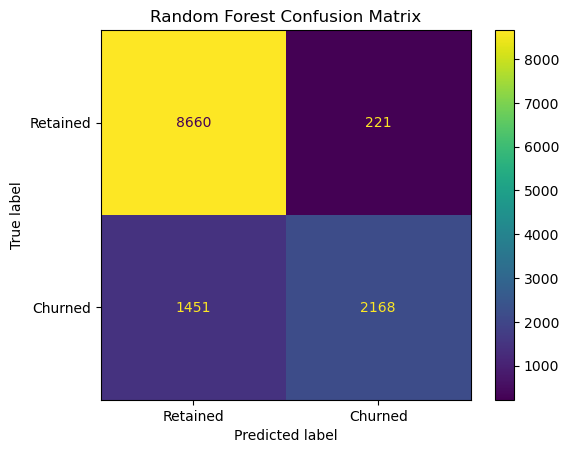

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Change this line:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(cmap='viridis')
plt.title("Random Forest Confusion Matrix")
plt.show()

### Comparison: Random Forest Classifier and Decision Tree Classifier

Compared to the Decision Tree, the Random Forest shows improved balance between precision and recall, particularly for churned customers. It also reduces overfitting, as seen in the smaller gap between training and test accuracy.
### Interpretation
By limiting the Random Forest to a depth of 8, the gap between training accuracy (88.3%) and test accuracy (86.6%) has closed significantly. This proves the model is not overfitting.
- The Confusion Matrix shows a major win for the Random Forest:
- Better Detection: It correctly identified 2,168 churners.
- Fewer Mistakes: It only made 221 "False Alarms" (predicting someone would leave when they actually stayed). This is much lower than the Decision Tree, meaning the Random Forest is more precise.

### Business Insight

The Random Forest is much more "reliable" for a real-world marketing campaign. Because it has very few False Alarms (only 221), the business can confidently offer discounts or retention gifts to predicted churners without wasting money on customers who were going to stay anyway.
While it still misses some churners (1,451), it is far more balanced and trustworthy than the single tree.



## Data Integration

To demonstrate data integration, the original dataset was separated into two analytical datasets: a customer profile dataset and a customer behaviour dataset. These were then merged using `Customer_ID`.

This simulates a common business scenario where customer demographic information and behavioural data are stored in separate tables and need to be combined before analysis.

This step simulates a real-world scenario where customer data is stored across multiple systems. Integrating these datasets enables a more comprehensive view of customer behaviour.

In [124]:
# Create a unique customer ID because the dataset does not already contain one
df = df.reset_index(drop=True)
df['Customer_ID'] = range(1, len(df) + 1)

# Create customer profile dataset
customer_profile = df[['Customer_ID', 'Age', 'Gender', 'Country', 'City', 'Membership_Years']].copy()

# Create customer behaviour dataset
customer_behaviour = df.drop(columns=['Age', 'Gender', 'Country', 'City', 'Membership_Years']).copy()

# Check shapes
print("Customer profile shape:", customer_profile.shape)
print("Customer behaviour shape:", customer_behaviour.shape)

Customer profile shape: (50000, 6)
Customer behaviour shape: (50000, 21)


As the original dataset did not include a customer identifier, a unique Customer_ID was created to support data integration and simulate how separate customer profile and behaviour tables could be merged in a business setting.

In [125]:
# Merging the dataset

df_integrated = pd.merge(
    customer_behaviour,
    customer_profile,
    on='Customer_ID',
    how='left'
)

print("Integrated dataset shape:", df_integrated.shape)
df_integrated.head()

Integrated dataset shape: (50000, 26)


,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,...,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter,Customer_ID,Age,Gender,Country,City,Membership_Years
0,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,...,953.33,2278.0,0,Q1,1,43.0,Male,France,Marseille,2.9
1,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,...,1067.47,3028.0,0,Q4,2,36.0,Male,UK,Manchester,1.6
2,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,...,1289.75,2317.0,0,Q4,3,45.0,Female,Canada,Vancouver,2.9
3,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,...,2340.92,2674.0,0,Q1,4,56.0,Female,USA,New York,2.6
4,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,...,3041.29,5354.0,0,Q4,5,35.0,Male,India,Delhi,3.1


## Clustering (K-mean)

While predictive models identify who is likely to churn, clustering helps explain why customers behave differently by grouping similar behavioural patterns.


Predicting that a customer will churn is only half the battle. To actually stop them, a business needs to know who they are and why they are leaving.
- The Goal: To segment the customer base into distinct "personas" (e.g., the "High-Spender at Risk" vs. the "Low-Engagement Browser").
- The Benefit: It allows for Targeted Action. You wouldn't send the same email to a loyal customer who is frustrated with support as you would to a new user who just hasn't logged in. Clustering provides the "why" behind the churn signal.
  
## Scaling the data


In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select features and DROP rows with missing values
X_cluster_data = df_encoded.drop('Churned', axis=1).dropna() # .dropna() fixes the error!

# 2. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_data)

# 3. Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=22, n_init=10)
# We use X_cluster_data.index to make sure the labels match the right rows
clusters = kmeans.fit_predict(X_scaled)

# 4. Attach back to a copy of the dataframe so we don't lose data
df_clustered = df.loc[X_cluster_data.index].copy()
df_clustered['Cluster'] = clusters

print(df_clustered['Cluster'].value_counts())

Cluster
0    9506
1    6228
2    2249
Name: count, dtype: int64


### Cluster Profiling

In [127]:
cluster_profile = df_clustered.groupby('Cluster').mean(numeric_only=True)
print(cluster_profile)

               Age  Membership_Years  Login_Frequency  Session_Duration_Avg  \
Cluster                                                                       
0        37.840206          3.005202         8.352725             22.057785   
1        38.045761          2.984655        19.376686             38.639660   
2        37.435305          2.950952        10.453980             25.216096   

         Pages_Per_Session  Cart_Abandonment_Rate  Wishlist_Items  \
Cluster                                                             
0                 6.986861              63.531738         2.93867   
1                12.595938              41.332757         7.26124   
2                 8.115562              59.452357         3.74522   

         Total_Purchases  Average_Order_Value  Days_Since_Last_Purchase  ...  \
Cluster                                                                  ...   
0              10.105965           120.224748                 29.533979  ...   
1              19.

The clustering results group customers into segments based on behaviour and engagement patterns. By analysing the average characteristics of each cluster, we can identify distinct customer profiles such as high-value customers, low-engagement users, and high-risk churn groups.

These clusters can be used to design targeted retention strategies, as different customer segments require different interventions.

## Optimisation

Predicting churn is only valuable if it leads to action. This section translates model outputs into a prioritisation strategy for customer retention.

In [128]:
# Create a copy of the integrated dataset for optimisation
optimisation_df = df_integrated.copy()

# Predict churn probability for all customers
optimisation_df['churn_prob'] = rf.predict_proba(X)[:, 1]

# Create a priority score using churn risk and customer value
optimisation_df['priority_score'] = optimisation_df['churn_prob'] * optimisation_df['Lifetime_Value']

# Select the top 1,000 customers to prioritise for retention
top_customers = optimisation_df.sort_values(
    by='priority_score',
    ascending=False
).head(1000)

top_customers.head()

,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,...,Churned,Signup_Quarter,Customer_ID,Age,Gender,Country,City,Membership_Years,churn_prob,priority_score
43141,10.0,24.0,6.6,68.3,7.0,28.0,278.92,25.0,21.9,5.5,...,1,Q1,43142,41.0,Male,USA,Houston,0.5,0.642396,5773.366553
40771,18.0,42.7,9.4,44.8,NaN,24.0,335.39,45.0,79.6,1.6,...,1,Q1,40772,26.0,Female,Canada,Calgary,2.4,0.620474,5114.896026
23759,21.0,47.8,9.3,57.4,5.0,24.0,230.54,51.0,25.3,12.4,...,1,Q2,23760,34.0,Male,Germany,Cologne,7.5,0.637866,4235.105377
27599,23.0,44.5,16.8,32.6,NaN,19.0,292.36,NaN,56.1,10.5,...,1,Q2,27600,42.0,Female,France,Paris,2.1,0.651564,4227.840467
23636,0.0,NaN,5.1,83.9,NaN,23.4,282.13,14.0,99.0,2.9,...,1,Q4,23637,NaN,Female,France,Toulouse,6.3,0.705554,4148.228187


This approach allows businesses to focus resources on customers who are both high risk and high value, maximising return on retention efforts.

## Additional Insight: Testing the Importance of Cart Abandonment Rate

I remove the Cart_Abandonment_Rate feature to assess its importance by evaluating the impact on model performance. While this feature was identified as a key predictor, this step helps determine whether churn is driven solely by this variable or influenced by multiple factors.

In [129]:
cols_to_drop = ['Cart_Abandonment_Rate']
X_train_new = X_train.drop(cols_to_drop, axis=1)
X_test_new = X_test.drop(cols_to_drop, axis=1)

In [130]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train_new, y_train)

print("Train accuracy:", model.score(X_train_new, y_train))
print("Test accuracy:", model.score(X_test_new, y_test))

Train accuracy: 0.8509066666666667
Test accuracy: 0.84784


This confirms that while Cart Abandonment Rate is an important predictor, churn is influenced by multiple behavioural factors rather than a single variable.

### Conclusion and Business Recommendations

This project demonstrates that machine learning can effectively predict customer churn and provide actionable insights for retention strategies.

The Random Forest model was identified as the most reliable due to its improved generalisation and balanced performance. Key drivers of churn include customer engagement, service interactions, and purchase behaviour.

By combining prediction, segmentation, and optimisation, this approach provides a practical framework for identifying at-risk customers and prioritising retention efforts.

Future work could explore more advanced models or real-time deployment to further enhance business impact.
